# City-scale climate metrics in an ensemble of CPRCM-emulator output

_Jesus Fernandez / Instituto de Fisica de Cantabria (IFCA), CSIC-Universidad de Cantabria_

This notebook is an illustrative walkthrough of daily CPRCM emulator output for a user-selected city and diagnostic metric. It inspects how individual emulator members behave and how they compare with each other, while building the cached products needed for efficient downstream analysis.

The active example uses daily maximum temperature (`tasmax`) and summarizes each year as the maximum 15-day running mean. That diagnostic is only one choice: the same workflow can also be pointed at other variables and yearly summaries, such as winter mean precipitation, by changing the metric configuration near the top of the notebook.

The workflow is organized around a reusable pattern: load emulator output, define a yearly diagnostic, build a cached member-level dataset (to lighten the two previous steps in case of rerun), convert the series into anomalies relative to a historical reference period, and compare the emulator members against observational and direct CPRCM references.

## Configuration

This block defines the selected city, local paths, active climate metric, diagnostic settings, and user-facing controls. In normal use, this is the main place to edit before re-running the notebook. FORCE_RECOMPUTE is used to overwrite the cache and read again from the original files.

In [1]:
CITY = "Paris"
VARIABLE = "tasmax"  # "pr", "tasmin", "tasmax"
DIAGNOSTIC_ID = "jjamean"  # "djfmean", "tn20", "tx15day", "rx1day"
REFERENCE_PERIOD = slice(1995, 2014)
HIGHLIGHT_MEMBERS = ["NorESM2-MM_historical_r1i1p1f1", "NorESM2-MM_ssp370_r1i1p1f1"]
GHCND_STATION = "FRM00007149"
FORCE_RECOMPUTE = False

We load libraries and other helper functions to identify available emulator files, parse member metadata from filenames, compute city-scale series, derive yearly diagnostics, and retrieve an observational reference series near the selected city. They are defined in the script [emulator_notebook_shared.py](../scripts/emulator_notebook_shared.py)

In [2]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

importlib.invalidate_caches()
sys.path.append(str((Path.cwd().parent / "scripts").resolve()))
from emulator_notebook_shared import *

config = build_config(
    city=CITY,
    variable=VARIABLE,
    diagnostic_id=DIAGNOSTIC_ID,
    reference_period=REFERENCE_PERIOD,
    highlight_members=HIGHLIGHT_MEMBERS,
    force_recompute=FORCE_RECOMPUTE,
)
globals().update(config)
GHCND_PATH = Path(f"../{GHCND_STATION}.csv")

print(f"City: {CITY}")
print(f"Variable: {VARIABLE}")
print(f"Diagnostic: {DIAGNOSTIC_ID}")
print(f"Data directory: {DATA_DIR}")
print(f"Cache file: {CACHE_PATH}")
print(f"Input directory exists: {DATA_DIR.exists()}")

City: Paris
Variable: tasmax
Diagnostic: jjamean
Data directory: ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Paris
Cache file: ../CACHE/Paris_tasmax_jjamean.nc
Input directory exists: True


## Build Or Load The Selected Diagnostics

This stage either loads previously computed caches or derives yearly diagnostics from all available emulator members. Caching matters because the underlying daily files are much larger than the final member-by-year summaries used in the plots.

The member series are then recentered relative to each driving model historical mean over the chosen reference period, and an observational reference is processed with the same diagnostic and anomaly definition for a consistent comparison.

In [3]:
common = load_common_analysis_inputs(config)
globals().update(common)

print(f"Found {len(files)} emulator files in {DATA_DIR}")
print(f"Metric cache: {CACHE_PATH}")
print(f"CPRCM cache: {CPRCM_CACHE_PATH}")
print(f"E-OBS metric cache: {EOBS_METRIC_CACHE_PATH}")

Found 113 emulator files in ../I4C_EMULATOR_CITY_DATA/ALPX-3i-Paris
Metric cache: ../CACHE/Paris_tasmax_jjamean.nc
CPRCM cache: ../CACHE/Paris_CPRCM_tasmax_jjamean.nc
E-OBS metric cache: ../CACHE/Paris_EOBS_tasmax_jjamean.nc


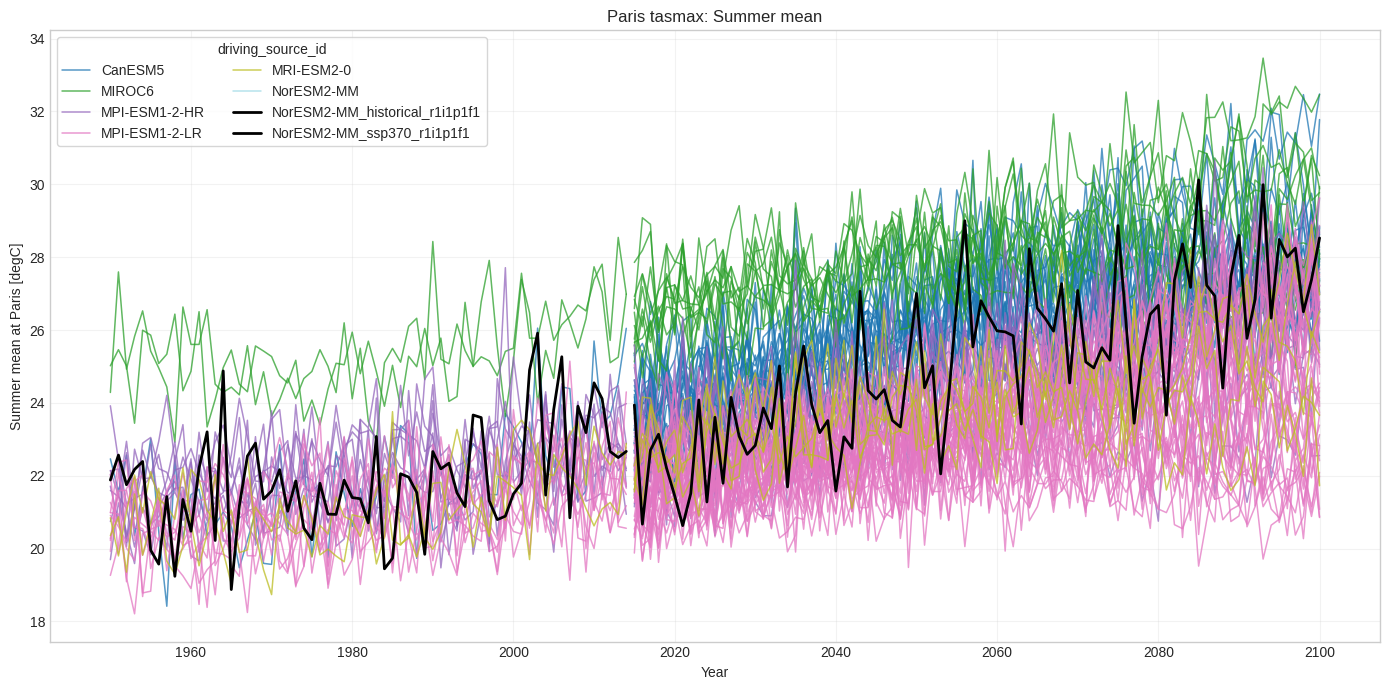

driving_source_id  experiment_id  scenario_group
CanESM5            historical     historical         1
                   ssp245         ssp               20
                   ssp370         ssp                1
                   ssp434         ssp                1
                   ssp460         ssp                2
MIROC6             historical     historical         2
                   ssp126         ssp                3
                   ssp245         ssp                2
                   ssp370         ssp                3
                   ssp434         ssp                1
                   ssp460         ssp                1
                   ssp585         ssp                1
MPI-ESM1-2-HR      historical     historical         8
                   ssp126         ssp                1
                   ssp245         ssp                2
                   ssp370         ssp                9
                   ssp585         ssp                1
MPI-ESM1-2-LR   

In [4]:
driving_source_colors = build_driving_source_colors(metric)

fig, ax = plt.subplots(figsize=(14, 7))
plot_member_ensemble(ax, metric, colors=driving_source_colors)
plot_highlight_member(ax, metric, HIGHLIGHT_MEMBERS)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {metric.title}",
    f"{metric.attrs.get('long_name', metric_name)} "
    f"[{metric.attrs.get('units', '')}]",
)
save_figure(
    fig,
    f"101_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_members",
    config,
)
plt.show()

summary.groupby(
    ["driving_source_id", "experiment_id", "scenario_group"]
).size().rename("n_files")

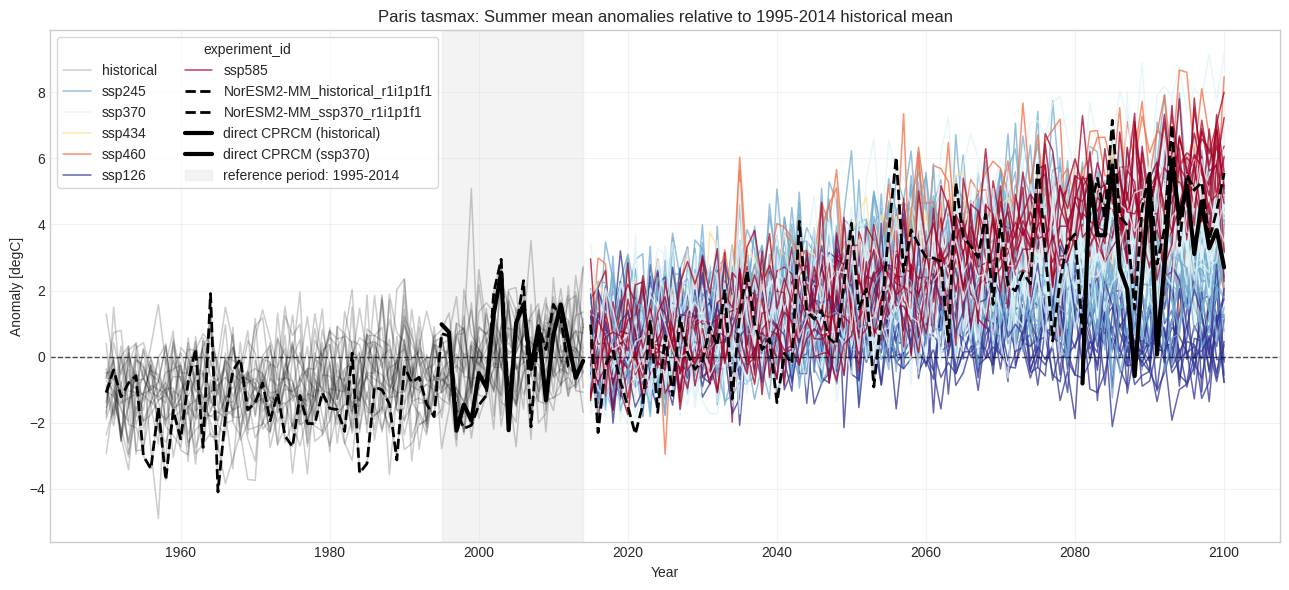

,emulator_reference,cprcm_reference
driving_source_id,,
CanESM5,23.309610,NaN
MIROC6,26.094812,NaN
MPI-ESM1-2-HR,22.629381,NaN
MPI-ESM1-2-LR,21.635437,NaN
MRI-ESM2-0,21.894403,NaN
NorESM2-MM,22.967760,25.702408


In [5]:
ssp_colors = build_experiment_colors(anomaly_metric)

fig, ax = plt.subplots(figsize=(13, 6))
plot_member_ensemble(
    ax,
    anomaly_metric,
    colors=ssp_colors,
    color_coord="experiment_id",
    legend_title="experiment_id",
    alpha_by_color_value={"historical": 0.2},
)
plot_highlight_member(
    ax,
    anomaly_metric,
    HIGHLIGHT_MEMBERS,
    linestyle="--",
)
plot_cprcm_anomaly(ax, cprcm_anomaly, color="black", linewidth=3.0)
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {cprcm_metric.title} anomalies "
    f"relative to {REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop} "
    "historical mean",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
    legend_title="experiment_id",
)
save_figure(
    fig,
    f"102_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_anomalies_emulator_cprcm_eobs",
    config,
)
plt.show()

pd.DataFrame(
    {
        "emulator_reference": historical_reference,
        "cprcm_reference": cprcm_historical_reference,
    }
)


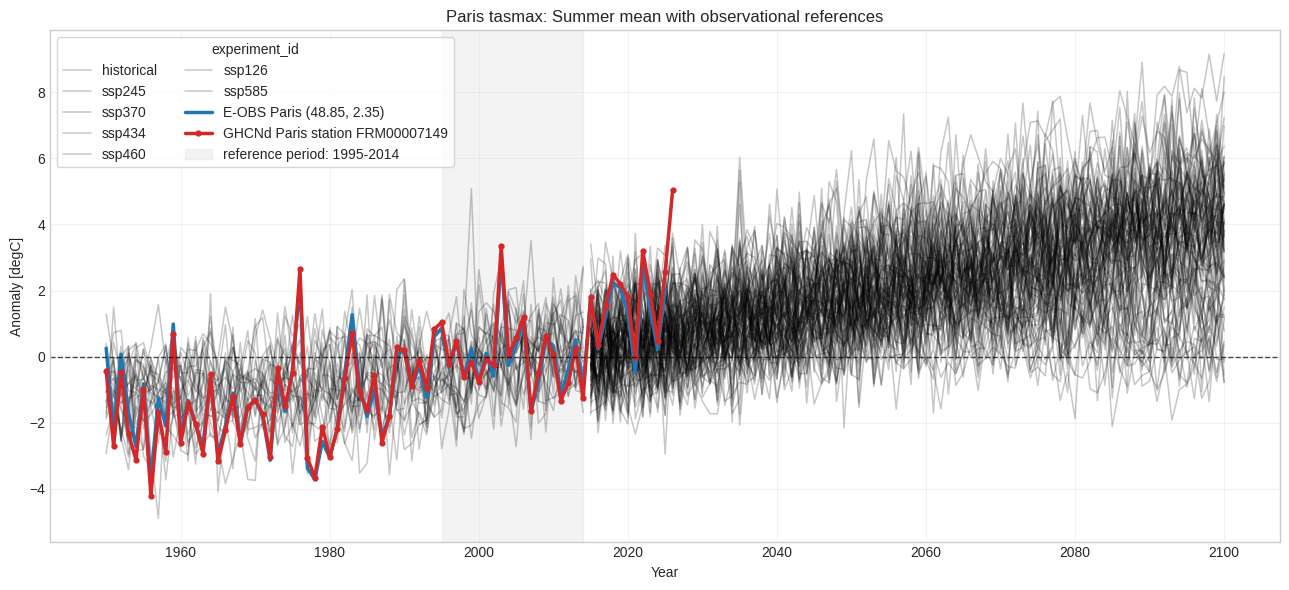

GHCNd observations: 1921-03-01 to 2026-08-31
GHCNd TMAX records: 30268
GHCNd historical reference: 24.61 degC


In [6]:
if CITY == "Paris":
    if not DIAGNOSTIC_ID in ["tx15day", "jjamean"]:
        raise ValueError(
            "The GHCNd Paris comparison supports tx15day and jjamean only"
        )

    ghcnd_columns = [
        "station", "date", "element", "value",
        "mflag", "qflag", "sflag", "obstime",
    ]
    ghcnd = pd.read_csv(
        GHCND_PATH,
        header=None,
        names=ghcnd_columns,
        na_values=-9999,
    )
    ghcnd = ghcnd.loc[
        ghcnd["element"] == "TMAX", ["date", "value"]
    ].dropna()
    ghcnd["time"] = pd.to_datetime(
        ghcnd["date"].astype(str), format="%Y%m%d"
    )
    ghcnd_series = xr.DataArray(
        ghcnd["value"].to_numpy(dtype=float) / 10.0,
        dims="time",
        coords={"time": ghcnd["time"]},
        name="ghcnd_tasmax",
        attrs={
            "units": "degC",
            "location_name": (
                f"Paris GHCNd station {GHCND_STATION}"
            ),
        },
    )
    ghcnd_metric = METRIC_FUNCTIONS[config["DIAGNOSTIC_ID"]](
        ghcnd_series, config
    ).rename("ghcnd_metric")
    # retain only 1950-2026, since the early years have too many missings
    ghcnd_metric = ghcnd_metric.sel(year=slice(1950, 2026))
    ghcnd_reference = ghcnd_metric.sel(
        year=slice(REFERENCE_PERIOD.start, REFERENCE_PERIOD.stop)
    ).mean()
    ghcnd_anomaly = (
        ghcnd_metric - ghcnd_reference
    ).rename("ghcnd_anomaly")

fig, ax = plt.subplots(figsize=(13, 6))
plot_member_ensemble(
    ax,
    anomaly_metric,
    colors=ssp_colors,
    color_coord="experiment_id",
    line_color=(0, 0, 0, 0.22),
    alpha=None,
    legend_title="experiment_id",
)
eobs_label = (
    f"E-OBS {eobs_metric.attrs['location_name']} "
    f"({eobs_metric.attrs['selected_lat']:.2f}, "
    f"{eobs_metric.attrs['selected_lon']:.2f})"
)
ax.plot(
    eobs_anomaly.year.values,
    eobs_anomaly.values,
    color="#1f77b4",
    linewidth=2.5,
    label=eobs_label,
)
if CITY == "Paris":
    ax.plot(
        ghcnd_anomaly.year.values,
        ghcnd_anomaly.values,
        color="#d62728",
        linewidth=2.5,
        marker="o",
        markersize=3.5,
        label=f"GHCNd Paris station {GHCND_STATION}",
    )
format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: {anomaly_metric.title} with "
    "observational references",
    f"Anomaly [{metric.attrs.get('units', '')}]",
    reference_period=REFERENCE_PERIOD,
    show_zero_line=True,
    legend_title="experiment_id",
)
save_figure(
    fig,
    f"103_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_anomalies_with_eobs",
    config,
)
plt.show()

eobs_reference.values.item()
if CITY == "Paris":
    print(
        f"GHCNd observations: {ghcnd.time.min().date()} "
        f"to {ghcnd.time.max().date()}"
    )
    print(f"GHCNd TMAX records: {len(ghcnd)}")
    print(
        f"GHCNd historical reference: "
        f"{ghcnd_reference.values.item():.2f} degC"
    )

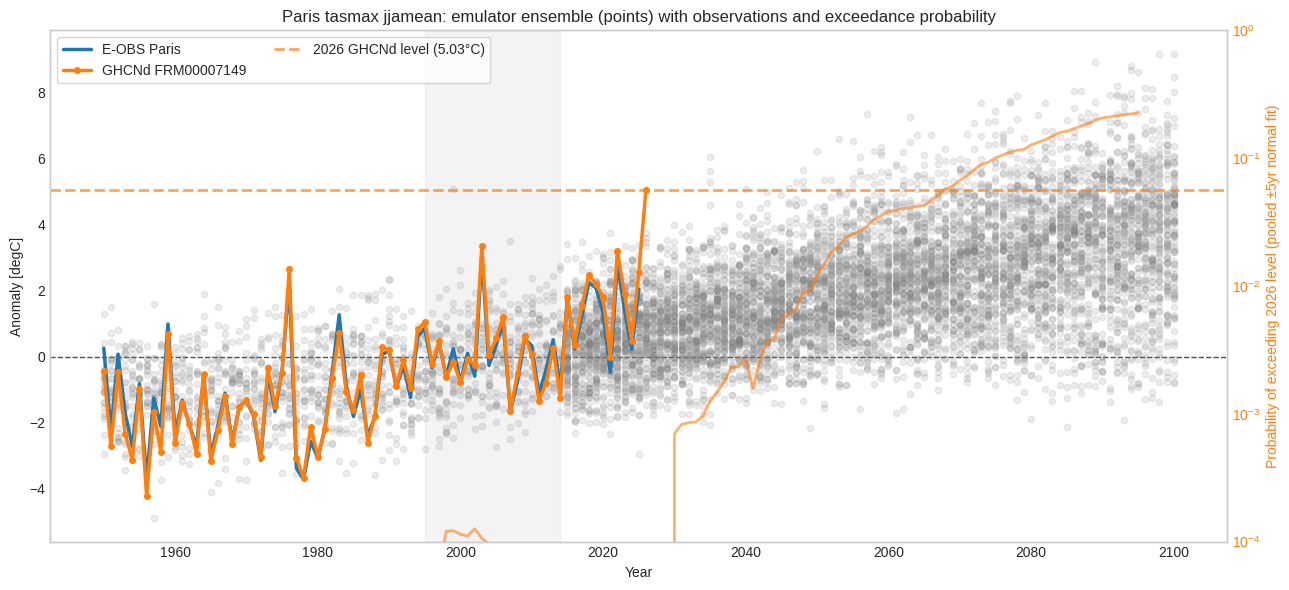

2026 GHCNd anomaly level: 5.03°C
Maximum exceedance probability: 22.6% (year 2095)


In [12]:
import numpy as np
from scipy.stats import genextreme, norm

if CITY == "Paris":
    ghcnd_2026_anomaly = (
        ghcnd_anomaly.sel(year=2026, drop=True).values.item()
    )
    
    fig, ax1 = plt.subplots(figsize=(13, 6))
    
    for member in anomaly_metric.member.values:
        member_series = anomaly_metric.sel(member=member)
        ax1.scatter(
            member_series.year.values,
            member_series.values,
            color=(0.5, 0.5, 0.5, 0.15),
            s=20,
            zorder=2,
        )
    
    ax1.plot(
        eobs_anomaly.year.values,
        eobs_anomaly.values,
        color="#1f77b4",
        linewidth=2.5,
        label=f"E-OBS {eobs_metric.attrs['location_name']}",
    )
    
    ax1.plot(
        ghcnd_anomaly.year.values,
        ghcnd_anomaly.values,
        color="#ff7f0e",
        linewidth=2.5,
        marker="o",
        markersize=4,
        label=f"GHCNd {GHCND_STATION}",
    )
    
    ax1.axhline(
        ghcnd_2026_anomaly,
        color="#ff7f0e",
        linewidth=2.0,
        linestyle="--",
        alpha=0.7,
        label=f"2026 GHCNd level ({ghcnd_2026_anomaly:.2f}°C)",
    )
    
    POOL_HALF_WINDOW = 5

    def pooled_gev_exceedance_probability(year, threshold, half_window=POOL_HALF_WINDOW, min_samples=8):
        # neighboring years share essentially the same forcing, so pooling
        # +-half_window years around the target year gives a larger, still
        # representative sample of the stochastic block-maxima for that period
        window_data = anomaly_metric.sel(
            year=slice(year - half_window, year + half_window)
        ).values.ravel()
        window_data = window_data[~np.isnan(window_data)]
        if len(window_data) < min_samples:
            return (window_data > threshold).sum() / len(window_data)
        shape, loc, scale = genextreme.fit(window_data)
        return genextreme.sf(threshold, shape, loc=loc, scale=scale)

    def pooled_normal_exceedance_probability(year, threshold, half_window=POOL_HALF_WINDOW, min_samples=8):
        # neighboring years share essentially the same forcing, so pooling
        # +-half_window years around the target year gives a larger, still
        # representative sample of the stochastic block-maxima for that period
        window_data = anomaly_metric.sel(
            year=slice(year - half_window, year + half_window)
        ).values.ravel()
        window_data = window_data[~np.isnan(window_data)]
        if len(window_data) < min_samples:
            return (window_data > threshold).sum() / len(window_data)
        loc, scale = norm.fit(window_data)
        return norm.sf(threshold, loc=loc, scale=scale)

    all_years = sorted(anomaly_metric.year.values)
    valid_years = [
        y for y in all_years
        if y - POOL_HALF_WINDOW >= all_years[0]
        and y + POOL_HALF_WINDOW <= all_years[-1]
    ]
    
    exceedance_prob_function = pooled_gev_exceedance_probability  if DIAGNOSTIC_ID in ["tx15day",] else pooled_normal_exceedance_probability
    exceedance_prob_label = "GEV" if DIAGNOSTIC_ID in ["tx15day",] else "normal"

    exceedance_prob = []
    years = []
    for year in valid_years:
        prob = pooled_gev_exceedance_probability(year, ghcnd_2026_anomaly)
        exceedance_prob.append(max(prob, np.finfo(float).tiny))
        years.append(year)
    
    ax2 = ax1.twinx()
    ax2.plot(
        years,
        exceedance_prob,
        color="#ff7f0e",
        linewidth=2,
        alpha=0.6,
        linestyle="-",
        label=f"Exceedance probability (pooled ±{POOL_HALF_WINDOW}yr {exceedance_prob_label} fit)",
    )
    ax2.set_yscale("log")
    ax2.set_ylabel(
        f"Probability of exceeding 2026 level (pooled ±{POOL_HALF_WINDOW}yr {exceedance_prob_label} fit)",
        color="#ff7f0e",
    )
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")
    ax2.set_ylim(bottom=1e-4, top=1)
    ax2.grid(False)
    
    ax1.set_title(
        f"{CITY} {VARIABLE} {DIAGNOSTIC_ID}: emulator ensemble (points) with "
        "observations and exceedance probability",
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel(
        f"Anomaly [{metric.attrs.get('units', '')}]",
    )
    ax1.axvspan(
        REFERENCE_PERIOD.start,
        REFERENCE_PERIOD.stop,
        color="lightgrey",
        alpha=0.25,
        zorder=1,
    )
    ax1.axhline(
        0,
        color="black",
        linewidth=1.0,
        linestyle="--",
        zorder=0,
        alpha=0.7,
    )
    ax1.legend(
        loc="upper left",
        frameon=True,
        ncols=2,
    )
    ax1.grid(False)
    plt.tight_layout()
    
    save_figure(
        fig,
        f"104_{CITY}_{VARIABLE}_{DIAGNOSTIC_ID}_points_exceedance",
        config,
    )
    plt.show()
    
    print(
        f"2026 GHCNd anomaly level: {ghcnd_2026_anomaly:.2f}°C"
    )
    print(
        f"Maximum exceedance probability: "
        f"{max(exceedance_prob):.1%} (year {years[exceedance_prob.index(max(exceedance_prob))]})"
    )


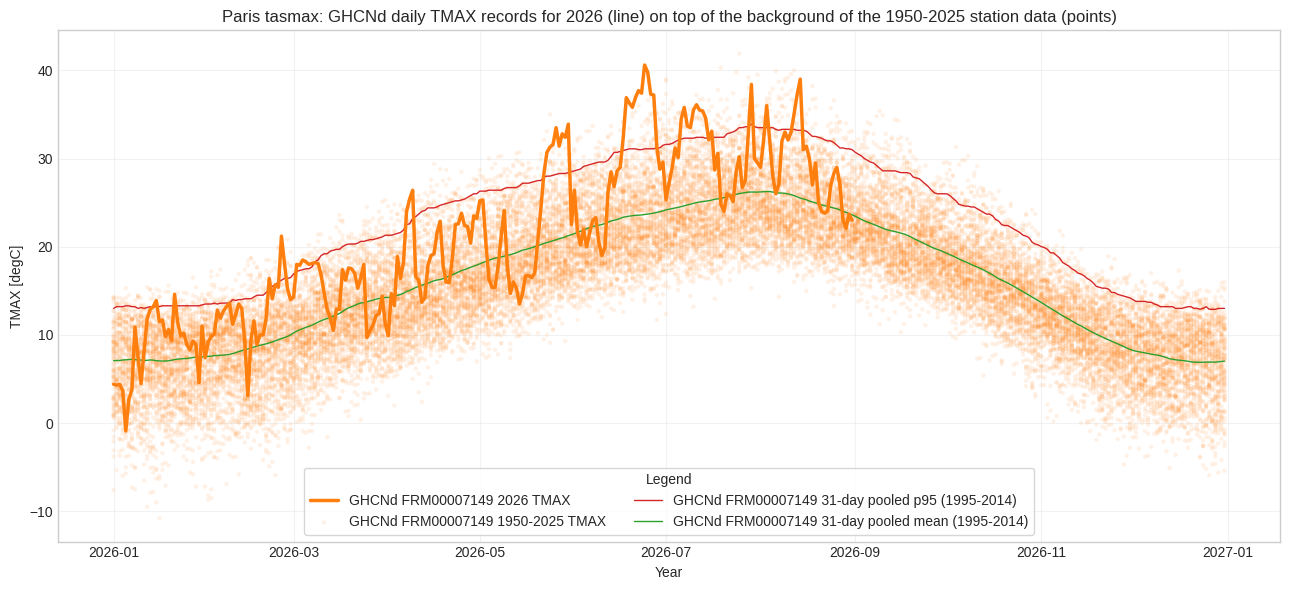

In 2026, out of 243 days, 51 days (21.0%) exceeded the 95th percentile and 187 days (77.0%) exceeded the mean of the reference period (1995-2014).


In [ ]:
# GHCNd Paris station daily TMAX records for a selected year (line) over
# daily records from all other years (points). No emulator; all observed.

highlighted_year = 2026
p95_pool_days = 31
p95_dates = pd.date_range(
    f"{highlighted_year}-01-01",
    f"{highlighted_year}-12-31",
    freq="D",
)
calendar_days = p95_dates.strftime("%m-%d")
calendar_day_count = len(p95_dates)

fig, ax = plt.subplots(figsize=(13, 6))
if CITY == "Paris":
    ghcnd_highlighted_data = ghcnd.loc[
        ghcnd["time"].dt.year == highlighted_year
    ]
    ax.plot(
        ghcnd_highlighted_data["time"],
        ghcnd_highlighted_data["value"] / 10.0,
        color="#ff7f0e",
        linewidth=2.5,
        label=f"GHCNd {GHCND_STATION} {highlighted_year} TMAX",
    )

    is_leap_day = (
        (ghcnd["time"].dt.month == 2)
        & (ghcnd["time"].dt.day == 29)
    )
    # Only omit February 29 when the selected year is not a leap year.
    omit_leap_day = is_leap_day & (calendar_day_count == 365)
    ghcnd_historical_data = ghcnd.loc[
        (ghcnd["time"].dt.year != highlighted_year) & ~omit_leap_day
    ].copy()
    ghcnd_historical_data["time"] = ghcnd_historical_data["time"].apply(
        lambda timestamp: timestamp.replace(year=highlighted_year)
    )
    ax.scatter(
        ghcnd_historical_data["time"],
        ghcnd_historical_data["value"] / 10.0,
        color=(1.0, 127 / 255, 14 / 255, 0.10),
        edgecolors="none",
        linewidths=0,
        s=10,
        label=f"GHCNd {GHCND_STATION} 1950-2025 TMAX",
    )

    # Pool neighboring calendar days from every reference year, excluding
    # the highlighted year when it belongs to the reference period.
    reference_data = ghcnd.loc[
        (ghcnd["time"].dt.year >= REFERENCE_PERIOD.start)
        & (ghcnd["time"].dt.year <= REFERENCE_PERIOD.stop)
        & (ghcnd["time"].dt.year != highlighted_year)
        & ~omit_leap_day
    ].copy()
    reference_data["calendar_day"] = reference_data["time"].dt.strftime("%m-%d")
    calendar_day_positions = {
        calendar_day: position
        for position, calendar_day in enumerate(calendar_days, start=1)
    }
    reference_data["calendar_position"] = reference_data["calendar_day"].map(
        calendar_day_positions
    )
    pool_offsets = np.arange(
        -(p95_pool_days // 2),
        p95_pool_days - (p95_pool_days // 2),
    )
    p95_daily = pd.Series(
        [
            reference_data.loc[
                reference_data["calendar_position"].isin(
                    ((position + pool_offsets - 1) % calendar_day_count) + 1
                ),
                "value",
            ].quantile(0.95)
            for position in range(1, calendar_day_count + 1)
        ],
        index=calendar_days,
    )
    mean_daily = pd.Series(
        [
            reference_data.loc[
                reference_data["calendar_position"].isin(
                    ((position + pool_offsets - 1) % calendar_day_count) + 1
                ),
                "value",
            ].mean()
            for position in range(1, calendar_day_count + 1)
        ],
        index=calendar_days,
    )

    ax.plot(
        p95_dates,
        p95_daily.to_numpy() / 10.0,
        color="#d62728",
        linewidth=1.0,
        linestyle="-",
        zorder=1,
        label=(
            f"GHCNd {GHCND_STATION} {p95_pool_days}-day pooled p95 "
            f"({REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop})"
        ),
    )
    ax.plot(
        p95_dates,
        mean_daily.to_numpy() / 10.0,
        color="#2ca02c",
        linewidth=1.0,
        linestyle="-",
        zorder=1,
        label=(
            f"GHCNd {GHCND_STATION} {p95_pool_days}-day pooled mean "
            f"({REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop})"
        ),
    )

format_time_series_axes(
    ax,
    f"{CITY} {VARIABLE}: GHCNd daily TMAX records for {highlighted_year} (line) "
    "on top of the background of the 1950-2025 station data (points)",
    "TMAX [degC]",
    legend_title="Legend",
)
save_figure(
    fig,
    f"105_{CITY}_{VARIABLE}_ghcnd_{highlighted_year}_daily_tmax",
    config,
)
plt.show()

# Days exceeding the 95th percentile and the mean of the reference period for the year highlighted_year, based on the pooled reference data.
ndays = len(ghcnd_highlighted_data)
ndays_exceeding_p95 = (ghcnd_highlighted_data["value"] > p95_daily.values[:ndays]).sum()
ndays_exceeding_mean = (ghcnd_highlighted_data["value"] > mean_daily.values[:ndays]).sum()
print(
    f"In {highlighted_year}, out of {ndays} days, "
    f"{ndays_exceeding_p95} days ({ndays_exceeding_p95/ndays*100:.1f}%) exceeded the 95th percentile "
    f"and {ndays_exceeding_mean} days ({ndays_exceeding_mean/ndays*100:.1f}%) exceeded the mean "
    f"of the reference period ({REFERENCE_PERIOD.start}-{REFERENCE_PERIOD.stop})."
)

In [13]:
historical_extremes = (
    anomaly_metric
    .sel(year=REFERENCE_PERIOD)
    .where(anomaly_metric.sel(year=REFERENCE_PERIOD) > 4, drop=True)
    .to_dataframe(name="anomaly")
    .dropna()
    .sort_values("anomaly", ascending=False)
)

historical_extremes

,,lon,lat,driving_source_id,experiment_id,scenario_group,variant_label,source_id,time_range,anomaly
member,year,,,,,,,,,
MPI-ESM1-2-HR_historical_r2i1p1f1,1999,2.359375,48.859375,MPI-ESM1-2-HR,historical,historical,r2i1p1f1,WRF451R-CI4C-emul-DeepESD1-t18,19500101-20141231,5.081314


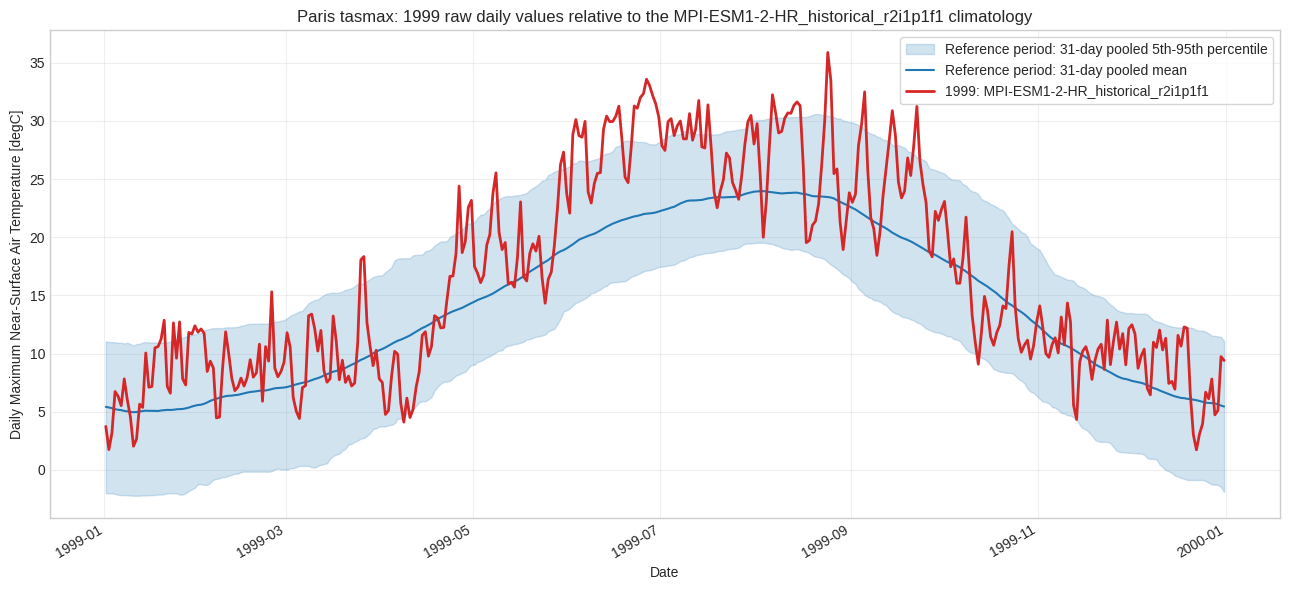

In [15]:
selected_member = "MPI-ESM1-2-HR_historical_r2i1p1f1"
highlighted_year = 1999
climatology_pool_days = 31

selected_member_path = next(
    path for path in files
    if parse_filename(path)["member_id"] == selected_member
)
with xr.open_dataset(selected_member_path, engine="netcdf4") as dataset:
    member_daily = compute_city_gridpoint_variable(dataset, config).load()

selected_daily = member_daily.sel(time=str(highlighted_year)).to_series()
reference_daily = member_daily.where(
    (member_daily.time.dt.year >= REFERENCE_PERIOD.start)
    & (member_daily.time.dt.year <= REFERENCE_PERIOD.stop)
    & (member_daily.time.dt.year != highlighted_year),
    drop=True,
).to_series()
reference_frame = reference_daily.rename("value").to_frame()
reference_frame["month_day"] = reference_frame.index.strftime("%m-%d")
selected_frame = selected_daily.rename("value").to_frame()
selected_frame["month_day"] = selected_frame.index.strftime("%m-%d")
calendar_days = selected_frame["month_day"].to_numpy()
calendar_day_count = len(calendar_days)
calendar_day_positions = {
    month_day: position
    for position, month_day in enumerate(calendar_days, start=1)
}
reference_frame["calendar_position"] = reference_frame["month_day"].map(
    calendar_day_positions
)
pool_offsets = np.arange(
    -(climatology_pool_days // 2),
    climatology_pool_days - (climatology_pool_days // 2),
)
climatology = pd.DataFrame(
    [
        reference_frame.loc[
            reference_frame["calendar_position"].isin(
                ((position + pool_offsets - 1) % calendar_day_count) + 1
            ),
            "value",
        ].agg(
            mean="mean",
            p05=lambda values: values.quantile(0.05),
            p95=lambda values: values.quantile(0.95),
        )
        for position in range(1, calendar_day_count + 1)
    ],
    index=calendar_days,
)
selected_frame = selected_frame.join(climatology, on="month_day")

fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(
    selected_frame.index,
    selected_frame["p05"],
    selected_frame["p95"],
    color="#1f77b4",
    alpha=0.2,
    label=(
        f"Reference period: {climatology_pool_days}-day pooled 5th-95th percentile"
    ),
)
ax.plot(
    selected_frame.index,
    selected_frame["mean"],
    color="#1f77b4",
    linewidth=1.5,
    label=f"Reference period: {climatology_pool_days}-day pooled mean",
)
ax.plot(
    selected_frame.index,
    selected_frame["value"],
    color="#d62728",
    linewidth=2.0,
    label=f"{highlighted_year}: {selected_member}",
)
ax.set(
    title=(
        f"{CITY} {VARIABLE}: {highlighted_year} raw daily values relative to "
        f"the {selected_member} climatology"
    ),
    xlabel="Date",
    ylabel=f"{member_daily.attrs.get('long_name', VARIABLE)} "
    f"[{member_daily.attrs.get('units', '')}]",
)
ax.legend(loc="best", frameon=True)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
save_figure(
    fig,
    f"106_{CITY}_{VARIABLE}_{selected_member}_{highlighted_year}_daily_climatology",
    config,
)
plt.show()